In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Import simulation functions
# We assume this notebook is in the same directory as sim_functions.py
import sim_functions as sf

# Set plot style
plt.rcParams['image.cmap'] = 'afmhot'

## 1. Define Simulation Parameters

Instead of relying on the default values in `params.py`, we define our simulation parameters explicitly here. 
This allows us to easily override settings like the magnet configuration and beam shifts.

In [3]:
# Simulation Settings
n_particles = 1e5
magnet_setting = 490.0

# Define shifts dictionary
# This dictionary controls magnet alignment and beam properties.
# We explicitly define it here to override defaults.
shifts = {
    'magnetSettings': magnet_setting,
    'q0': {'x': 0.0, 'y': 0, 'ang_x': 0, 'ang_y': 0, 'ang_z': 0},
    'q1': {'x': 0.0, 'y': 0.0, 'ang_x': 0, 'ang_y': 0, 'ang_z': 0},
    'q2': {'x': 0.0, 'y': 0.0, 'ang_x': 0, 'ang_y': 0, 'ang_z': 0},
    'beam': {'fx0': 0.0, 'fy0': 0.0, 'fz0': -2, 'fbeamfocus': 0.0},
    'dd_corr': {'x': 0.0, 'y': 0.0, 'ang_x': 0, 'ang_y': 0, 'ang_z': 0},
    'dd': {'x': 0.0, 'y': 0.0, 'ang_x': 0, 'ang_y': 0, 'ang_z': 0},
}

# Initialize random number generator for reproducibility
rng = np.random.default_rng(123)

## 2. Initialize the Beamline

### Algorithm and Definitions
The beamline initialization process constructs the accelerator lattice using the `xtrack` library. The function `sf.line_init` performs the following steps:
1.  **Magnetic Strength Calculation**: Converts the magnet settings (in kG or Tesla) to normalized strengths ($k_1$ for quadrupoles, $k_0$ for dipoles) based on the reference particle's momentum and charge.
2.  **Element Creation**: Defines the physical elements of the beamline:
    *   **Drifts**: Free space where particles propagate in straight lines.
    *   **Quadrupoles**: Focusing/defocusing magnets (`q0`, `q1`, `q2`).
    *   **Dipoles**: Bending magnets (`corr`, `dd`).
    *   **Apertures**: Limits on the transverse position ($x, y$) to simulate the beam pipe and magnet apertures.
3.  **Alignment and Misalignment**: Applies shifts and rotations (defined in the `shifts` dictionary) to simulate realistic alignment errors.
4.  **Line Assembly**: Combines all elements into an `xtrack.Line` object.

**Outputs:**
*   `line`: The `xtrack.Line` object containing the sequence of elements.
*   `env`: The `xtrack.Environment` object managing the elements and variables.
*   `ref`: A dictionary containing the reference particle properties (momentum, mass, charge).

We use `sf.line_init` to create the xtrack Line object based on our parameters.

In [4]:
# Initialize the beamline elements
# Returns:
# - line: The xtrack Line object
# - env: The environment
# - ref: Reference particle properties
line, env, ref = sf.line_init(shifts, verbose=True)

## 3. Generate Particles

### Algorithm and Definitions
The particle generation process creates the initial ensemble of particles to be tracked. The function `sf.generate_secondary_particles` operates as follows:
1.  **Primary Beam Generation**: Uses `sf.GenerateGaussianBeam` to create a Gaussian distribution of particles in 6D phase space ($x, y, z, p_x, p_y, p_z$). The distribution is defined by the beam energy, emittance, and spot size parameters.
2.  **Propagation to Target**: Propagates the particles in a vacuum to the position of the target (e.g., Aluminum foil or Beryllium window).
3.  **Secondary Production (Optional)**: If enabled, simulates the interaction with the target to generate secondary particles (e.g., positrons from electron impact), sampling energy and angles based on physical models (Bremsstrahlung-like).
4.  **State Collection**: Returns a list of particle "states", where each state is a list: `[x, y, z, px, py, pz, mass, charge]`.

**Outputs:**
*   `states`: A list of lists, where each inner list represents a particle's properties in the format `[x, y, z, px, py, pz, mass, charge]`.
*   `particles`: An `xtrack.Particles` object created from `states` using `sf.particles_from_states`. This object is optimized for tracking within the `xtrack` engine.

We generate the initial distribution of secondary particles (positrons).

In [5]:
print(f"Generating {int(n_particles)} particles...")

# Generate particle states (raw coordinates)
states = sf.generate_secondary_particles(shifts, n_particles, verbose=True, rng=rng)

# Convert states to xtrack Particles object ready for tracking
particles = sf.particles_from_states(states, ref, verbose=True)

Generating 100000 particles...
Finised creating beam
created 0 particles
created 10000 particles
created 20000 particles
created 30000 particles
created 40000 particles
created 50000 particles
created 60000 particles
created 70000 particles
created 80000 particles
created 90000 particles
Loaded 100000 particles


## 4. Track Particles

We track the particles through the beamline. The `track_line` function returns the history of the particles at each element.

In [6]:
print("Tracking particles...")
# Track particles through the line
# Returns:
# - particle_list: List of Particle objects at each element
# - s_values: Longitudinal positions of elements
particle_list, s_values = sf.track_line(line, particles)

Tracking particles...
ELEMENT 0: dr0 || s=0.000:3.373 m
ELEMENT 1: rots_q0 || s=3.373:3.373 m
ELEMENT 2: spacer || s=3.373:3.373 m
ELEMENT 3: rotx_q0 || s=3.373:3.373 m
ELEMENT 4: spacer || s=3.373:3.373 m
ELEMENT 5: roty_q0 || s=3.373:3.373 m
ELEMENT 6: spacer || s=3.373:3.373 m
ELEMENT 7: xy_q0 || s=3.373:3.373 m
ELEMENT 8: spacer || s=3.373:3.373 m
ELEMENT 9: a_q0 || s=3.373:3.373 m
ELEMENT 10: q0 || s=3.373:4.347 m
ELEMENT 11: a_q0 || s=4.347:4.347 m
ELEMENT 12: spacer || s=4.347:4.347 m
ELEMENT 13: xy_restore_q0 || s=4.347:4.347 m
ELEMENT 14: spacer || s=4.347:4.347 m
ELEMENT 15: roty_restore_q0 || s=4.347:4.347 m
ELEMENT 16: spacer || s=4.347:4.347 m
ELEMENT 17: rotx_restore_q0 || s=4.347:4.347 m
ELEMENT 18: spacer || s=4.347:4.347 m
ELEMENT 19: rots_restore_q0 || s=4.347:4.347 m
ELEMENT 20: dr0.1 || s=4.347:5.603 m
ELEMENT 21: rots_q1 || s=5.603:5.603 m
ELEMENT 22: spacer || s=5.603:5.603 m
ELEMENT 23: rotx_q1 || s=5.603:5.603 m
ELEMENT 24: spacer || s=5.603:5.603 m
ELEMENT 25: 

## 5. Analyze and Plot Results

### Understanding the Output

The `particle_list` contains the state of all particles at each element in the beamline.
- `particle_list[0]`: Initial state
- `particle_list[-1]`: Final state (at the detector)

The `s_values` array gives the longitudinal position (z) of each element.

In [7]:
# Check dimensions
print(f"Number of tracking steps: {len(particle_list)}")
print(f"Number of s-positions: {len(s_values)}")

# Get the final particle distribution
final_particles = particle_list[-1]

# Identify surviving particles (state > 0)
alive_mask = final_particles.state > 0
n_alive = np.sum(alive_mask)
print(f"Particles surviving to the end: {n_alive} ({n_alive/n_particles*100:.2f}%)")

Number of tracking steps: 104
Number of s-positions: 104
Particles surviving to the end: 2975 (2.97%)


### Plotting Trajectories
We can visualize the path of a few particles through the system.

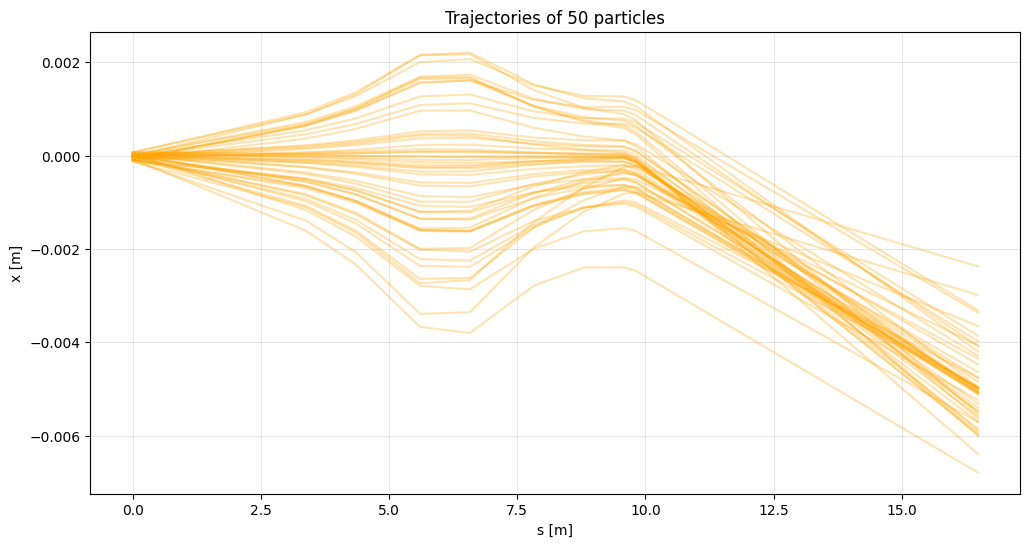

In [8]:
# Plot trajectories of a subset of surviving particles
n_plot = 50
indices = np.where(alive_mask)[0][:n_plot]

plt.figure(figsize=(12, 6))
for idx in indices:
    # Extract x position for this particle across all steps
    x_traj = [p_step.x[idx] for p_step in particle_list]
    plt.plot(s_values, x_traj, alpha=0.3, color='orange')

plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title(f'Trajectories of {n_plot} particles')
plt.grid(True, alpha=0.3)
plt.show()

### Plotting Final Distribution
Here we plot the spatial distribution of particles at the end of the line.

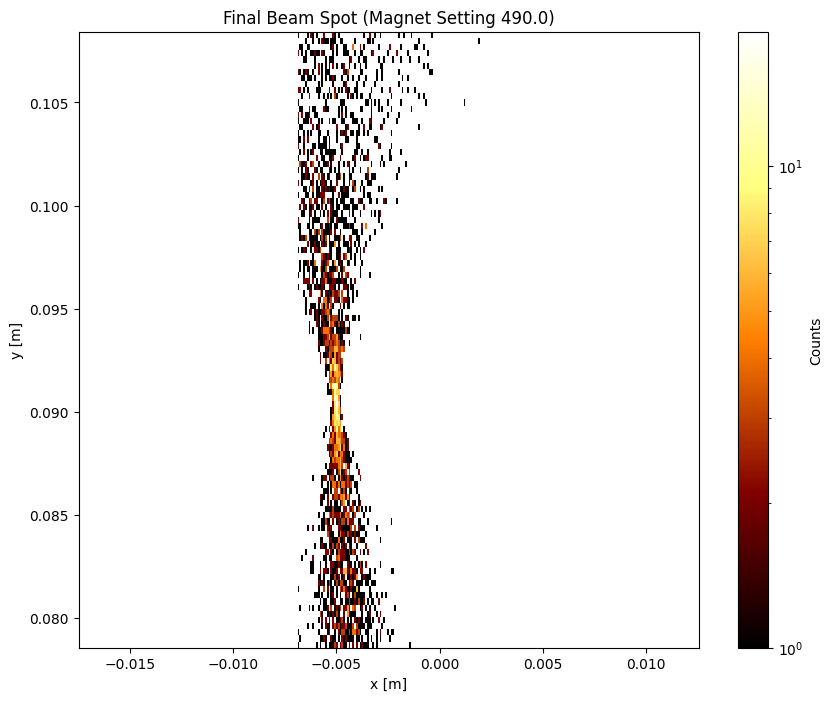

In [9]:
# Plot final distribution at the detector
x_final = final_particles.x[alive_mask]
y_final = final_particles.y[alive_mask]

plt.figure(figsize=(10, 8))
plt.hist2d(x_final, y_final, bins=100, cmap='afmhot', norm=LogNorm())
plt.colorbar(label='Counts')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'Final Beam Spot (Magnet Setting {magnet_setting})')
plt.axis('equal')
plt.show()